In [60]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
df=pd.read_csv("/content/drive/MyDrive/hackathon/crop_yield.csv")

In [63]:
df.shape

(19689, 10)

In [64]:
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [66]:
df.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


In [67]:
df.isnull().sum()

,0
Crop,0
Crop_Year,0
Season,0
State,0
Area,0
Production,0
Annual_Rainfall,0
Fertilizer,0
Pesticide,0
Yield,0


In [68]:
df.columns = df.columns.str.strip()

In [69]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (19689, 10)


In [70]:
X = df[
    [
        "Crop",
        "Crop_Year",
        "Season",
        "State",
        "Area",
        "Production",
        "Annual_Rainfall",
        "Fertilizer",
        "Pesticide"
    ]
]

y = df["Yield"]


In [71]:
categorical_features = [
    "Crop",
    "Season",
    "State"
]


In [72]:
numerical_features = [
    "Crop_Year",
    "Area",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide"
]



In [73]:
df = df.drop("Production", axis=1)

In [74]:
print(df.columns)

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Annual_Rainfall',
       'Fertilizer', 'Pesticide', 'Yield'],
      dtype='object')


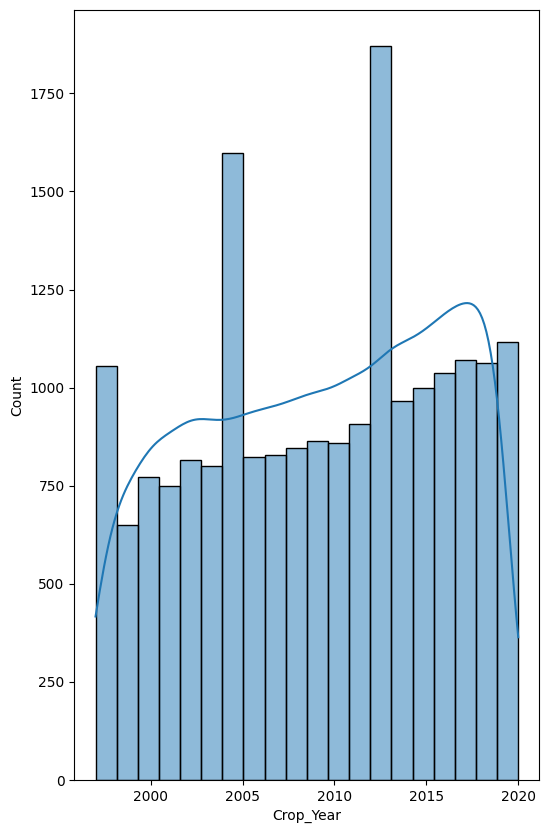

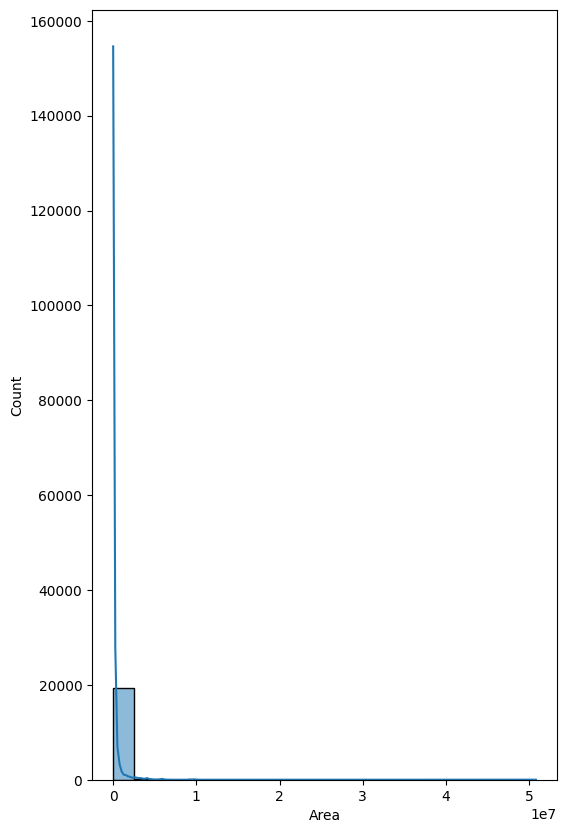

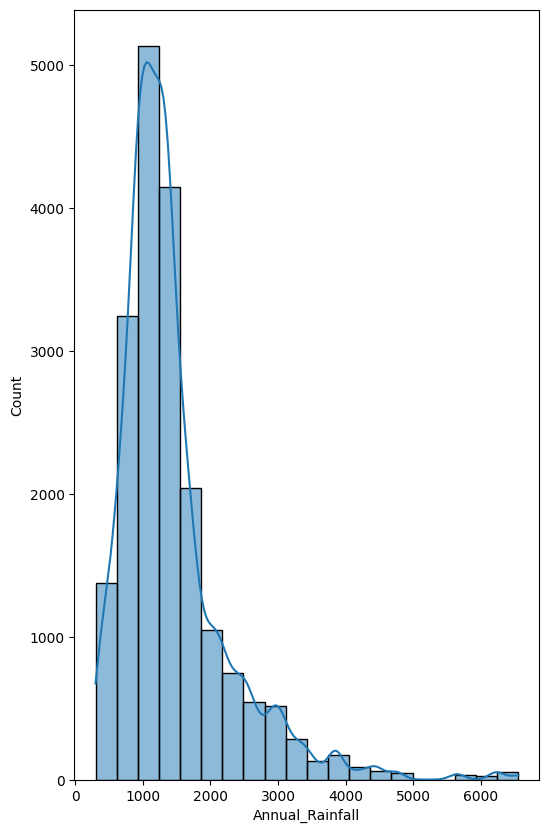

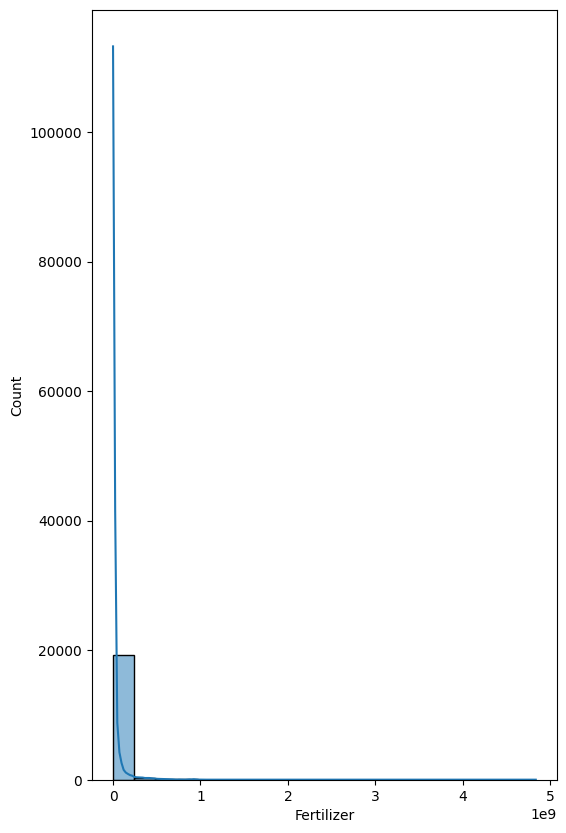

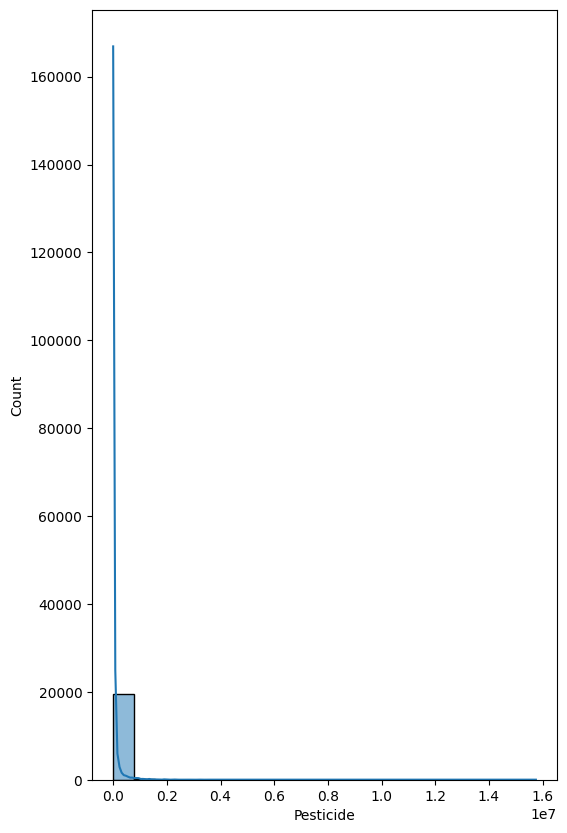

In [75]:

for col in numerical_features :
  plt.figure (figsize=(6,10))
  sns.histplot(df[col],kde=True,bins=20)

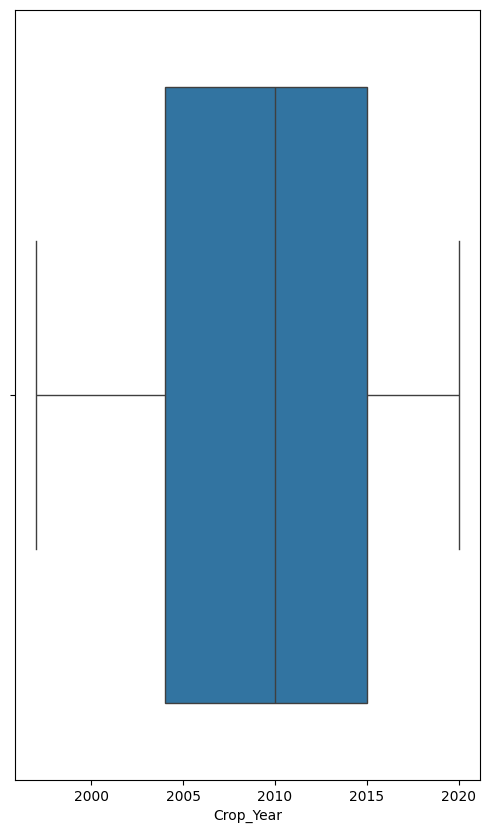

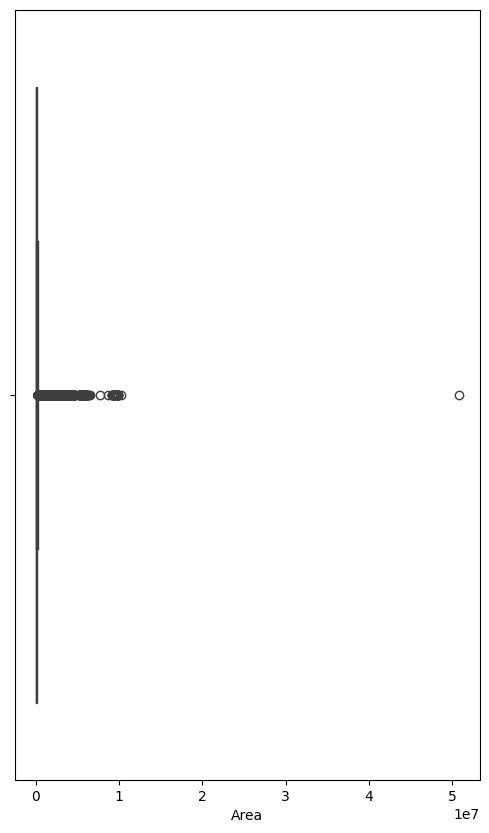

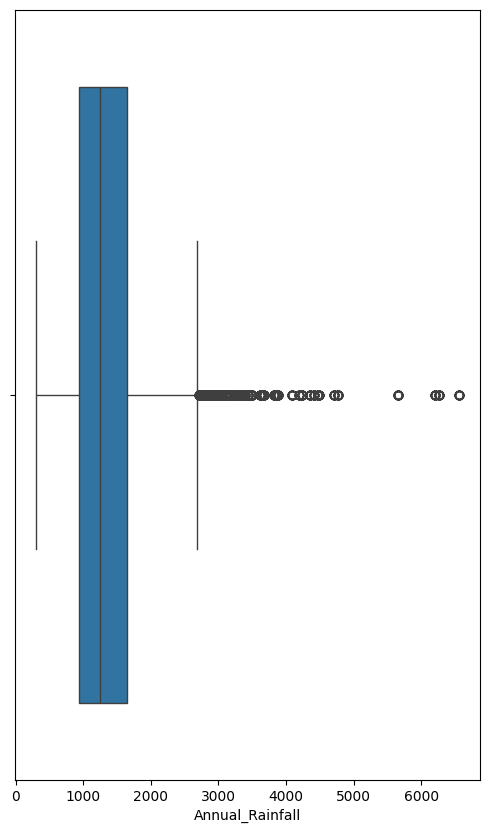

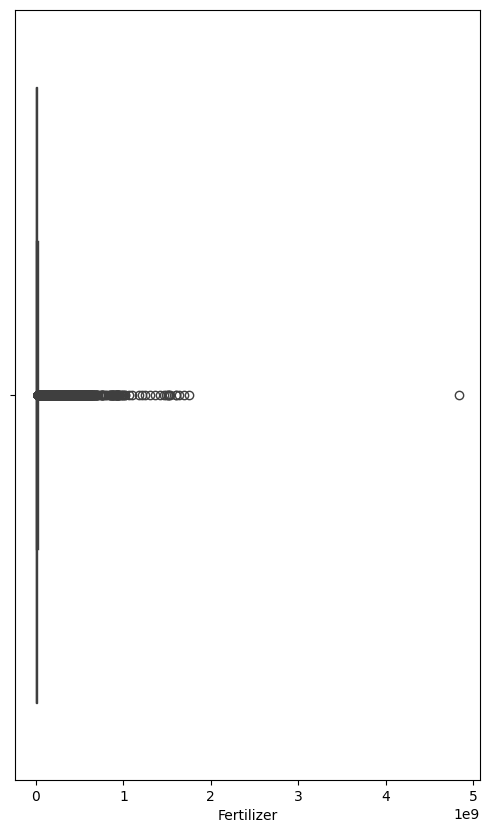

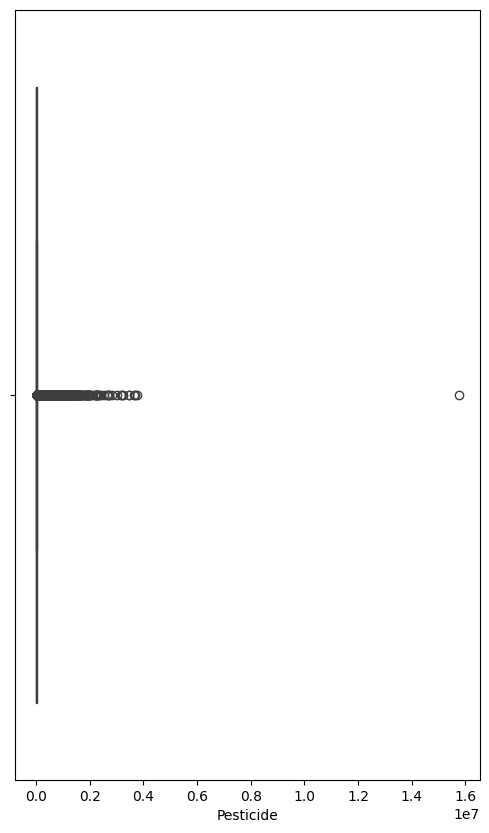

In [76]:
for col in numerical_features :
  plt.figure(figsize=(6,10))
  sns.boxplot(x=df[col])

In [77]:
df["Fertilizer_per_Area"] = (
    df["Fertilizer"] / df["Area"].replace(0, np.nan)
)

df["Pesticide_per_Area"] = (
    df["Pesticide"] / df["Area"].replace(0, np.nan)
)

In [78]:
df["Fertilizer_per_Area"] = (
    df["Fertilizer_per_Area"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

df["Pesticide_per_Area"] = (
    df["Pesticide_per_Area"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

In [79]:
X = df.drop(columns=["Yield"])

y = df["Yield"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Yield")

Features:
['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Fertilizer_per_Area', 'Pesticide_per_Area']

Target:
Yield


In [80]:
years = sorted(df["Crop_Year"].unique())

print("Years available:")
print(years)

Years available:
[np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


In [81]:
split_index = int(len(years) * 0.80)

train_years = years[:split_index]
test_years = years[split_index:]

print("Training years:", train_years)
print("Testing years:", test_years)

Training years: [np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]
Testing years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


In [82]:
train_df = df[df["Crop_Year"].isin(train_years)]
test_df = df[df["Crop_Year"].isin(test_years)]

X_train = train_df.drop(columns=["Yield"])
y_train = train_df["Yield"]

X_test = test_df.drop(columns=["Yield"])
y_test = test_df["Yield"]

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 15404
Testing samples: 4285


In [83]:
categorical_features = [
    "Crop",
    "Season",
    "State"
]

numerical_features = [
    "Crop_Year",
    "Area",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide",
    "Fertilizer_per_Area",
    "Pesticide_per_Area"
]

In [84]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),

        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)


In [85]:

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [86]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

In [87]:
model = TransformedTargetRegressor(
    regressor=model_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

In [88]:
print("Training model...")

model.fit(X_train, y_train)

print("Training completed!")

Training model...
Training completed!


In [89]:
y_pred = model.predict(X_test)



In [90]:
y_pred = np.maximum(y_pred, 0)

In [91]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("\n========== MODEL PERFORMANCE ==========")

print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)


========== MODEL PERFORMANCE ==========
MAE  : 10.731364094094426
RMSE : 149.3071014603145
R²   : 0.9692471680352185


In [92]:
comparison = pd.DataFrame({
    "Actual_Yield": y_test.values,
    "Predicted_Yield": y_pred
})

print(comparison.head(20))

    Actual_Yield  Predicted_Yield
0       3.912500         0.727238
1       0.493077         0.722157
2       0.481818         0.719929
3       1.744545         1.098393
4       1.827143         1.098393
5      41.427692        33.244127
6       0.445833         0.722157
7       0.511111         0.719929
8       0.520000         0.719929
9   13934.122500     12073.912628
10      0.130000         0.719929
11      0.536667         0.719929
12      2.633077         1.798151
13      2.201429         2.161375
14      0.491429         0.719929
15      0.585000         0.719929
16      4.829091         2.090609
17      3.750000         2.333775
18      2.288000         3.597219
19      2.750000         3.497934


In [93]:
comparison["Error"] = (
    comparison["Actual_Yield"] -
    comparison["Predicted_Yield"]
)

comparison["Absolute_Error"] = (
    comparison["Error"].abs()
)

print(comparison.head(20))

    Actual_Yield  Predicted_Yield        Error  Absolute_Error
0       3.912500         0.727238     3.185262        3.185262
1       0.493077         0.722157    -0.229080        0.229080
2       0.481818         0.719929    -0.238111        0.238111
3       1.744545         1.098393     0.646152        0.646152
4       1.827143         1.098393     0.728750        0.728750
5      41.427692        33.244127     8.183565        8.183565
6       0.445833         0.722157    -0.276323        0.276323
7       0.511111         0.719929    -0.208818        0.208818
8       0.520000         0.719929    -0.199929        0.199929
9   13934.122500     12073.912628  1860.209872     1860.209872
10      0.130000         0.719929    -0.589929        0.589929
11      0.536667         0.719929    -0.183262        0.183262
12      2.633077         1.798151     0.834926        0.834926
13      2.201429         2.161375     0.040053        0.040053
14      0.491429         0.719929    -0.228501        0

In [94]:
comparison["Crop"] = X_test["Crop"].values

crop_performance = (
    comparison
    .groupby("Crop")
    .apply(
        lambda x: pd.Series({
            "MAE": mean_absolute_error(
                x["Actual_Yield"],
                x["Predicted_Yield"]
            ),
            "Actual_Mean": x["Actual_Yield"].mean(),
            "Predicted_Mean": x["Predicted_Yield"].mean()
        }),
        include_groups=False
    )
)

print(crop_performance)

                               MAE  Actual_Mean  Predicted_Mean
Crop                                                           
Arecanut                  2.239754     2.967092        0.730787
Arhar/Tur                 0.332049     0.972093        0.720267
Bajra                     0.881768     2.033936        1.428820
Banana                   11.465663    36.777495       26.443927
Barley                    1.065325     1.848353        0.870539
Black pepper              0.521610     0.852606        0.723445
Cardamom                  0.627092     0.092837        0.719929
Cashewnut                 0.421727     0.648818        0.722152
Castor seed               0.299706     0.744302        0.719536
Coconut                1195.156827  9132.666533     9173.836149
Coriander                 0.643032     1.046589        0.719415
Cotton(lint)              0.833303     1.834712        1.461613
Cowpea(Lobia)             0.401601     0.871882        0.720648
Dry chillies              2.376116     3

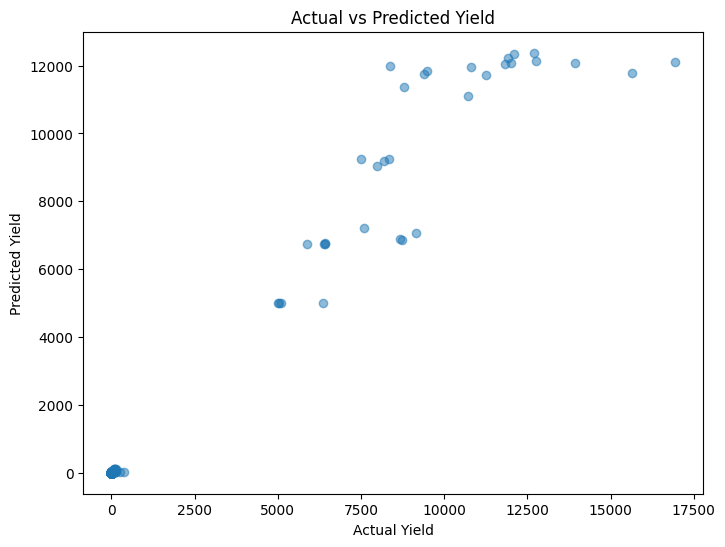

In [95]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")

plt.show()

In [96]:

joblib.dump(
    model,
    "yield_prediction_model.pkl",
    compress=3
)

['yield_prediction_model.pkl']

In [97]:
import os

size_mb = os.path.getsize("yield_prediction_model.pkl") / (1024 * 1024)

print(f"Model size: {size_mb:.2f} MB")

Model size: 4.20 MB


model training

In [98]:
model = joblib.load("yield_prediction_model.pkl")


In [99]:
farmer_data = pd.DataFrame({
    "Crop": ["turmeric"],
    "Crop_Year": [2026],
    "Season": ["whole year"],
    "State": ["Maharashtra"],
    "Area": [10.0],
    "Annual_Rainfall": [1700],
    "Fertilizer": [300000],
    "Pesticide": [5000]
})


In [100]:
farmer_data["Fertilizer_per_Area"] = (
    farmer_data["Fertilizer"] /
    farmer_data["Area"]
)

farmer_data["Pesticide_per_Area"] = (
    farmer_data["Pesticide"] /
    farmer_data["Area"]
)

In [101]:
predicted_yield = model.predict(farmer_data)[0]

print(
    f"Predicted Yield: {predicted_yield:.2f}"
)

Predicted Yield: 0.72


In [102]:
joblib.dump(model,"yeild_prediction_model.pkl")

['yeild_prediction_model.pkl']